# Stock Price Prediction Using LSTM
## Minor Project | Part 1 — Exploratory Data Analysis

### Abstract
The art of forecasting stock prices has been a challenging task for researchers and analysts alike. This project aims to build an LSTM (Long Short-Term Memory) deep learning model to predict stock prices based on historical data. This notebook performs a thorough exploratory data analysis (EDA) to understand the dataset's structure, trends, and patterns before modeling.

> **INPUT**: Raw historical stock price CSV file (downloaded from Yahoo Finance)  
> **OUTPUT**: Visual insights and statistical understanding of the stock data

---

### 1. INITIALIZATION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. LOAD DATASET

In [3]:
import yfinance as yf
import pandas as pd

df = yf.download('GOOGL', start='2015-01-01', end='2025-12-31', interval='1d')
df.reset_index(inplace=True)
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df.to_csv('../data/raw/google_stock_price.csv', index=False)

print(f"Downloaded {len(df)} rows")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Downloaded 2765 rows
           Date       Close        High         Low        Open    Volume
2760 2025-12-23  314.128876  314.718457  309.102415  309.412195  25478700
2761 2025-12-24  313.869049  314.858343  311.700593  314.548563  10097400
2762 2025-12-26  313.289459  314.868334  312.060314  314.258778  10899000
2763 2025-12-29  313.339417  313.799084  310.401482  311.150955  19621800
2764 2025-12-30  313.629242  316.727067  312.240205  312.280185  17380900


### 3. BASIC STATISTICS

In [4]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Date Range ===")
print(f"From: {df['Date'].min().date()}  To: {df['Date'].max().date()}")
print(f"Total trading days: {len(df)}")
print(f"\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

=== Date Range ===
From: 2015-01-02  To: 2025-12-30
Total trading days: 2765

=== Missing Values ===
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [11]:
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,Date,Close,High,Low,Open,Volume
count,2765,2765.00,2765.00,2765.00,2765.00,2.765000e+03
mean,2020-06-29 19:22:56.202531584,93.58,94.56,92.54,93.53,3.527957e+07
min,2015-01-02 00:00:00,24.65,24.81,24.34,24.76,9.312000e+06
25%,2017-09-29 00:00:00,49.19,49.47,48.75,49.19,2.502200e+07
50%,2020-06-30 00:00:00,73.19,73.71,72.23,72.79,3.104540e+07
75%,2023-03-29 00:00:00,133.62,134.94,132.16,133.52,4.013200e+07
max,2025-12-30 00:00:00,323.00,328.38,318.74,325.77,2.571620e+08
std,NaN,57.37,58.03,56.66,57.35,1.690263e+07


### 4. STOCK PRICE HISTORY

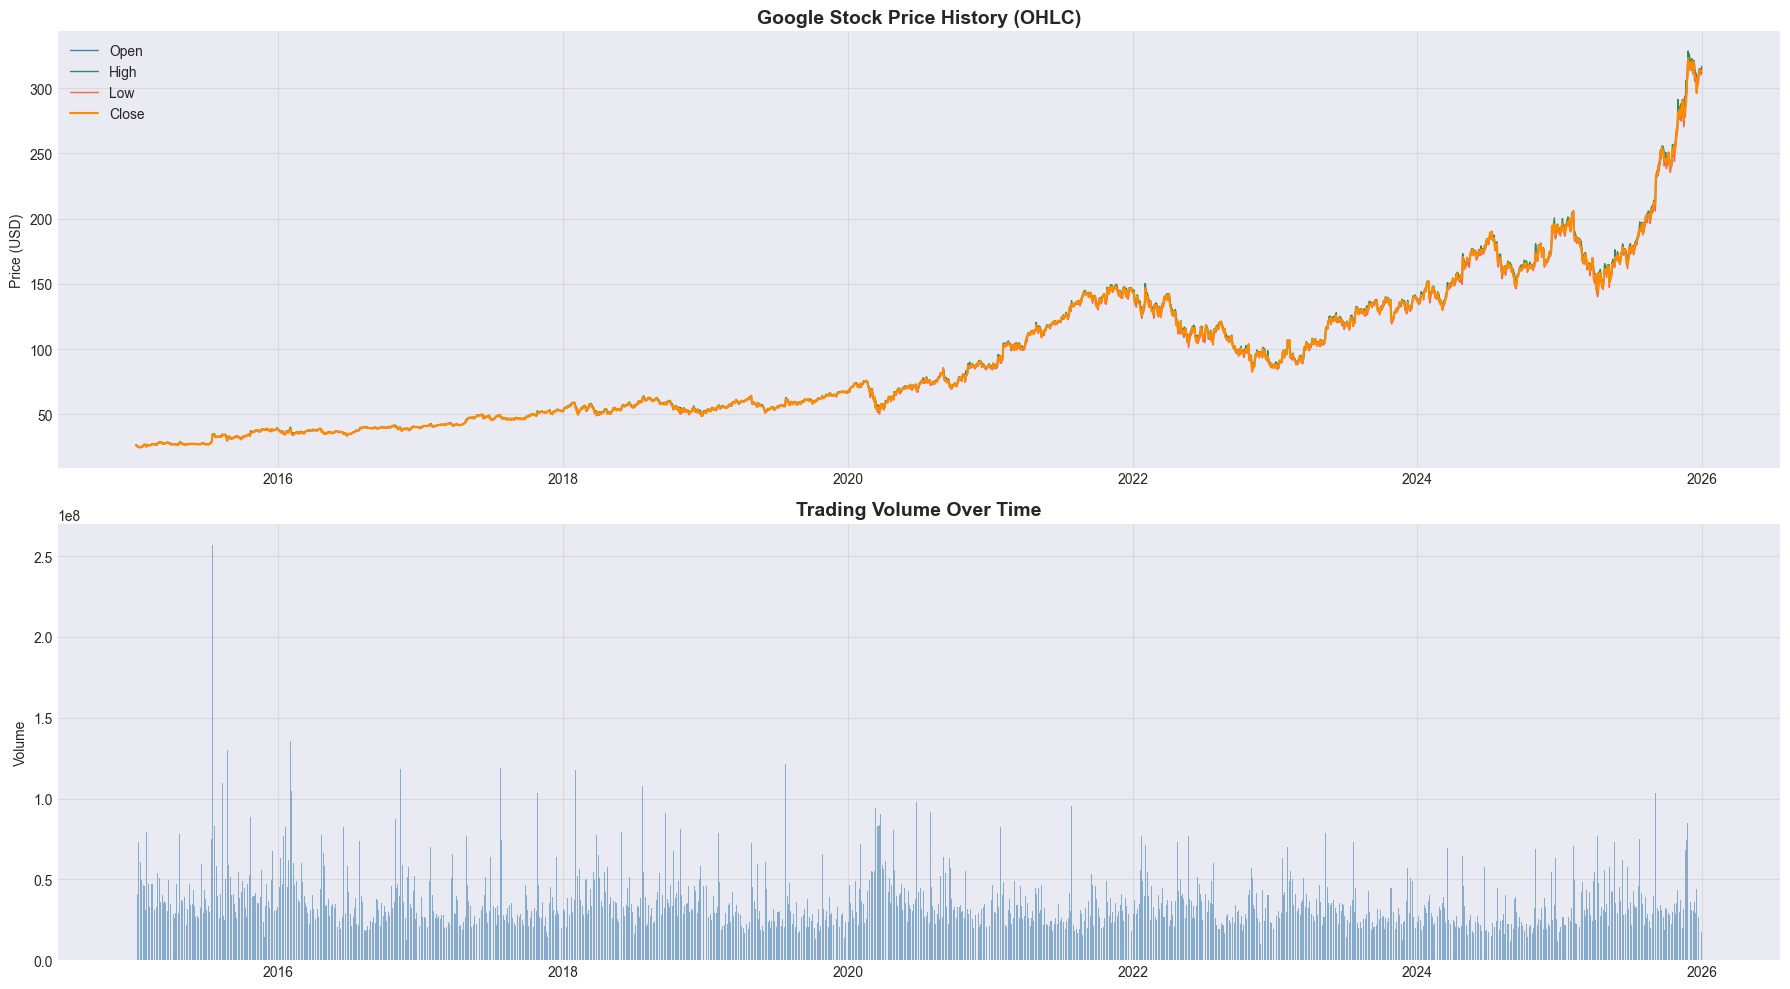

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Plot 1: OHLC prices
axes[0].plot(df['Date'], df['Open'],  label='Open',      color='steelblue',   linewidth=1)
axes[0].plot(df['Date'], df['High'],  label='High',      color='seagreen',    linewidth=1)
axes[0].plot(df['Date'], df['Low'],   label='Low',       color='tomato',      linewidth=1)
axes[0].plot(df['Date'], df['Close'], label='Close',     color='darkorange',  linewidth=1.5)
axes[0].set_title('Google Stock Price History (OHLC)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(color='lightgray', alpha=0.7)

# Plot 2: Volume
axes[1].bar(df['Date'], df['Volume'], color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(color='lightgray', alpha=0.7)

plt.tight_layout()
plt.savefig('../data/raw/eda_ohlc_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. MOVING AVERAGES ANALYSIS

Moving averages smooth out short-term fluctuations and highlight longer-term trends. We analyze **100-day** and **200-day** moving averages — two of the most widely used indicators by professional traders.

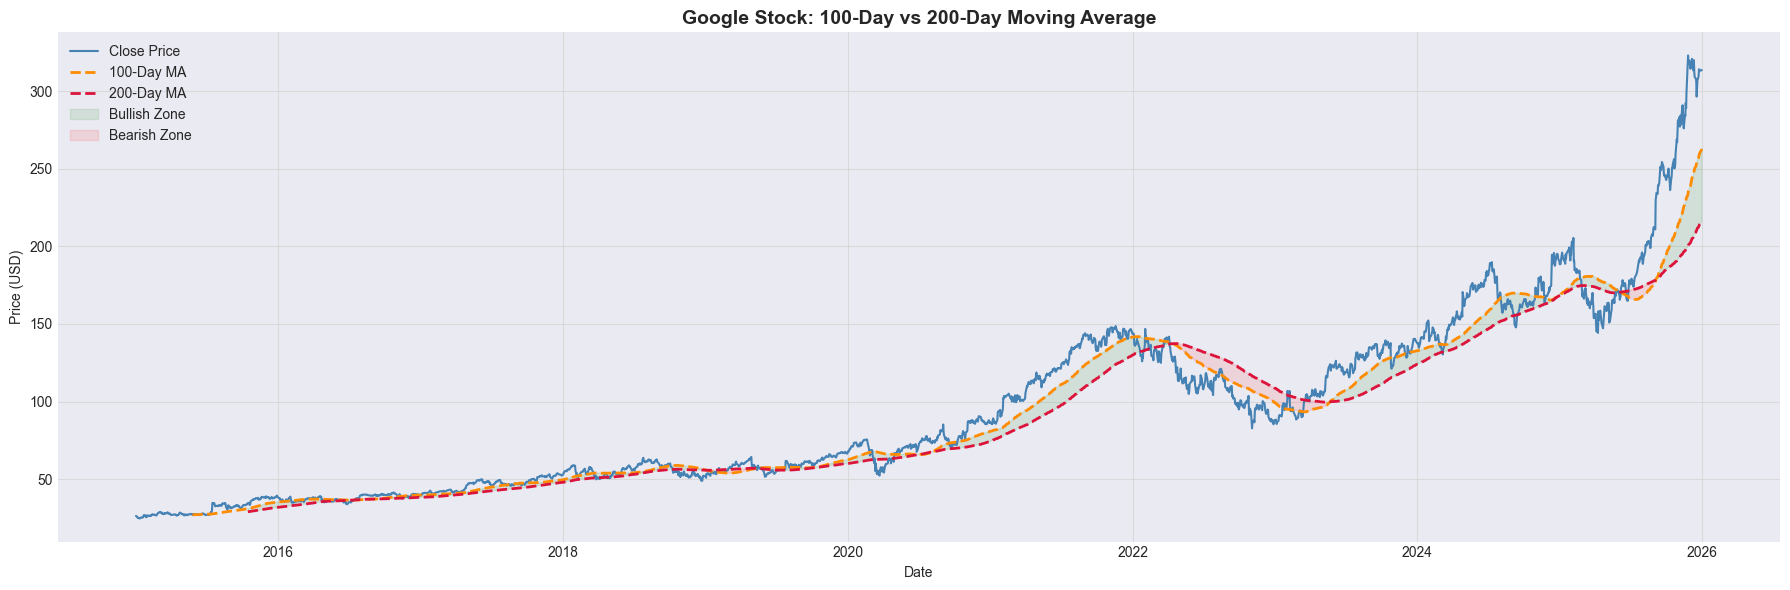

Observation: When 100-day MA crosses above 200-day MA → Bullish signal (Golden Cross)
             When 100-day MA crosses below 200-day MA → Bearish signal (Death Cross)


In [13]:
df['MA_100'] = df['Close'].rolling(window=100).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(18, 6))
plt.plot(df['Date'], df['Close'],  label='Close Price',     color='steelblue',  linewidth=1.5)
plt.plot(df['Date'], df['MA_100'], label='100-Day MA',      color='darkorange', linewidth=2, linestyle='--')
plt.plot(df['Date'], df['MA_200'], label='200-Day MA',      color='crimson',    linewidth=2, linestyle='--')
plt.fill_between(df['Date'], df['MA_100'], df['MA_200'],
                 where=df['MA_100'] >= df['MA_200'], alpha=0.1, color='green', label='Bullish Zone')
plt.fill_between(df['Date'], df['MA_100'], df['MA_200'],
                 where=df['MA_100'] <  df['MA_200'], alpha=0.1, color='red',   label='Bearish Zone')
plt.title('Google Stock: 100-Day vs 200-Day Moving Average', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(color='lightgray', alpha=0.7)
plt.tight_layout()
plt.savefig('../data/raw/eda_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: When 100-day MA crosses above 200-day MA → Bullish signal (Golden Cross)")
print("             When 100-day MA crosses below 200-day MA → Bearish signal (Death Cross)")

### 6. DAILY RETURNS & VOLATILITY

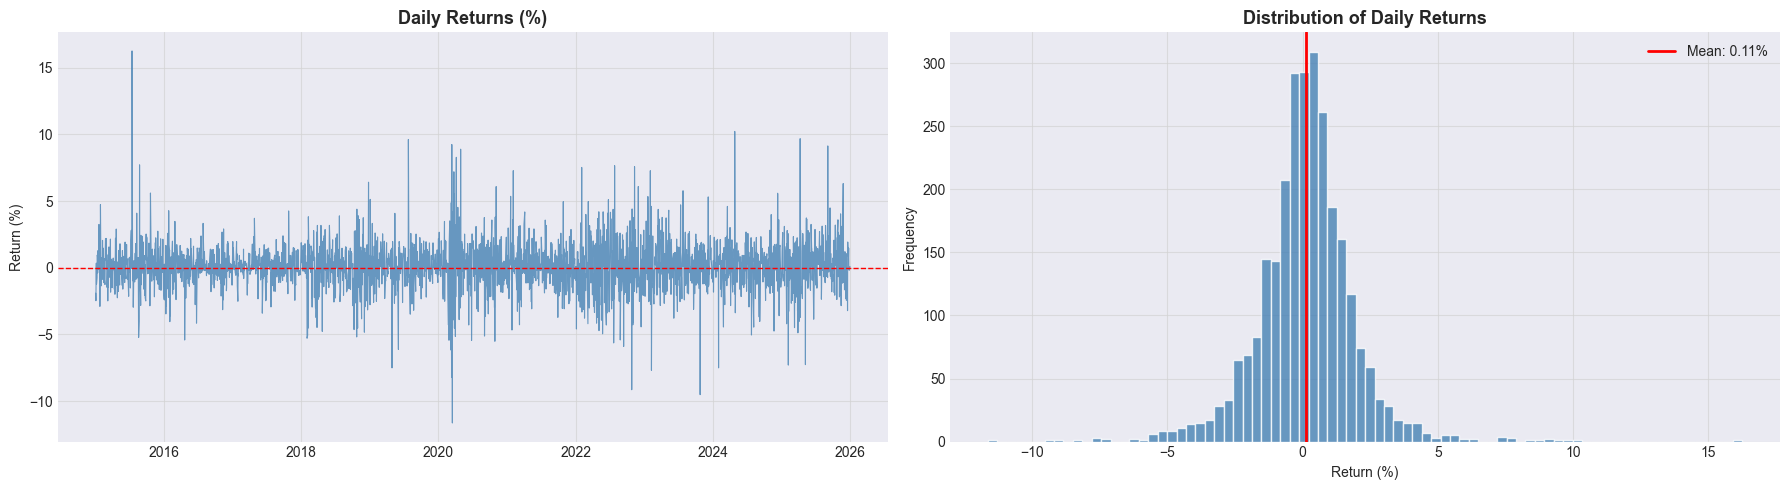

Average Daily Return : 0.1062%
Return Std Deviation : 1.8172%  (Volatility)
Max Single Day Gain  : 16.26%
Max Single Day Loss  : -11.63%


In [14]:
df['Daily_Return'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(df['Date'], df['Daily_Return'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title('Daily Returns (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(color='lightgray', alpha=0.7)

axes[1].hist(df['Daily_Return'].dropna(), bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(df['Daily_Return'].mean(), color='red', linewidth=2, label=f"Mean: {df['Daily_Return'].mean():.2f}%")
axes[1].set_title('Distribution of Daily Returns', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(color='lightgray', alpha=0.7)

plt.tight_layout()
plt.savefig('../data/raw/eda_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Daily Return : {df['Daily_Return'].mean():.4f}%")
print(f"Return Std Deviation : {df['Daily_Return'].std():.4f}%  (Volatility)")
print(f"Max Single Day Gain  : {df['Daily_Return'].max():.2f}%")
print(f"Max Single Day Loss  : {df['Daily_Return'].min():.2f}%")

### 7. CORRELATION ANALYSIS

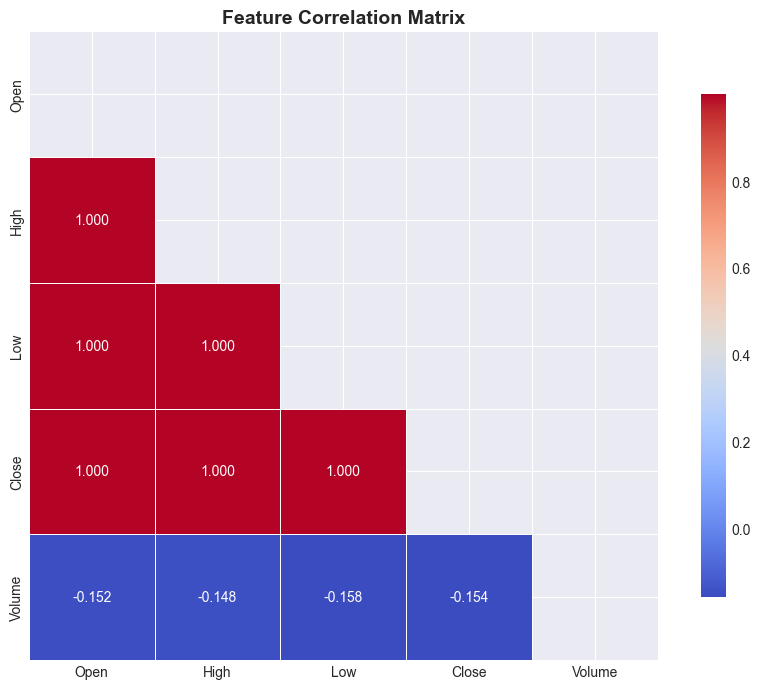

Observation: Open, High, Low and Close are highly correlated (as expected).
Volume shows much weaker correlation with price features.


In [5]:
corr_features = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix   = df[corr_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/raw/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Open, High, Low and Close are highly correlated (as expected).")
print("Volume shows much weaker correlation with price features.")

### 8. SEASONAL DECOMPOSITION

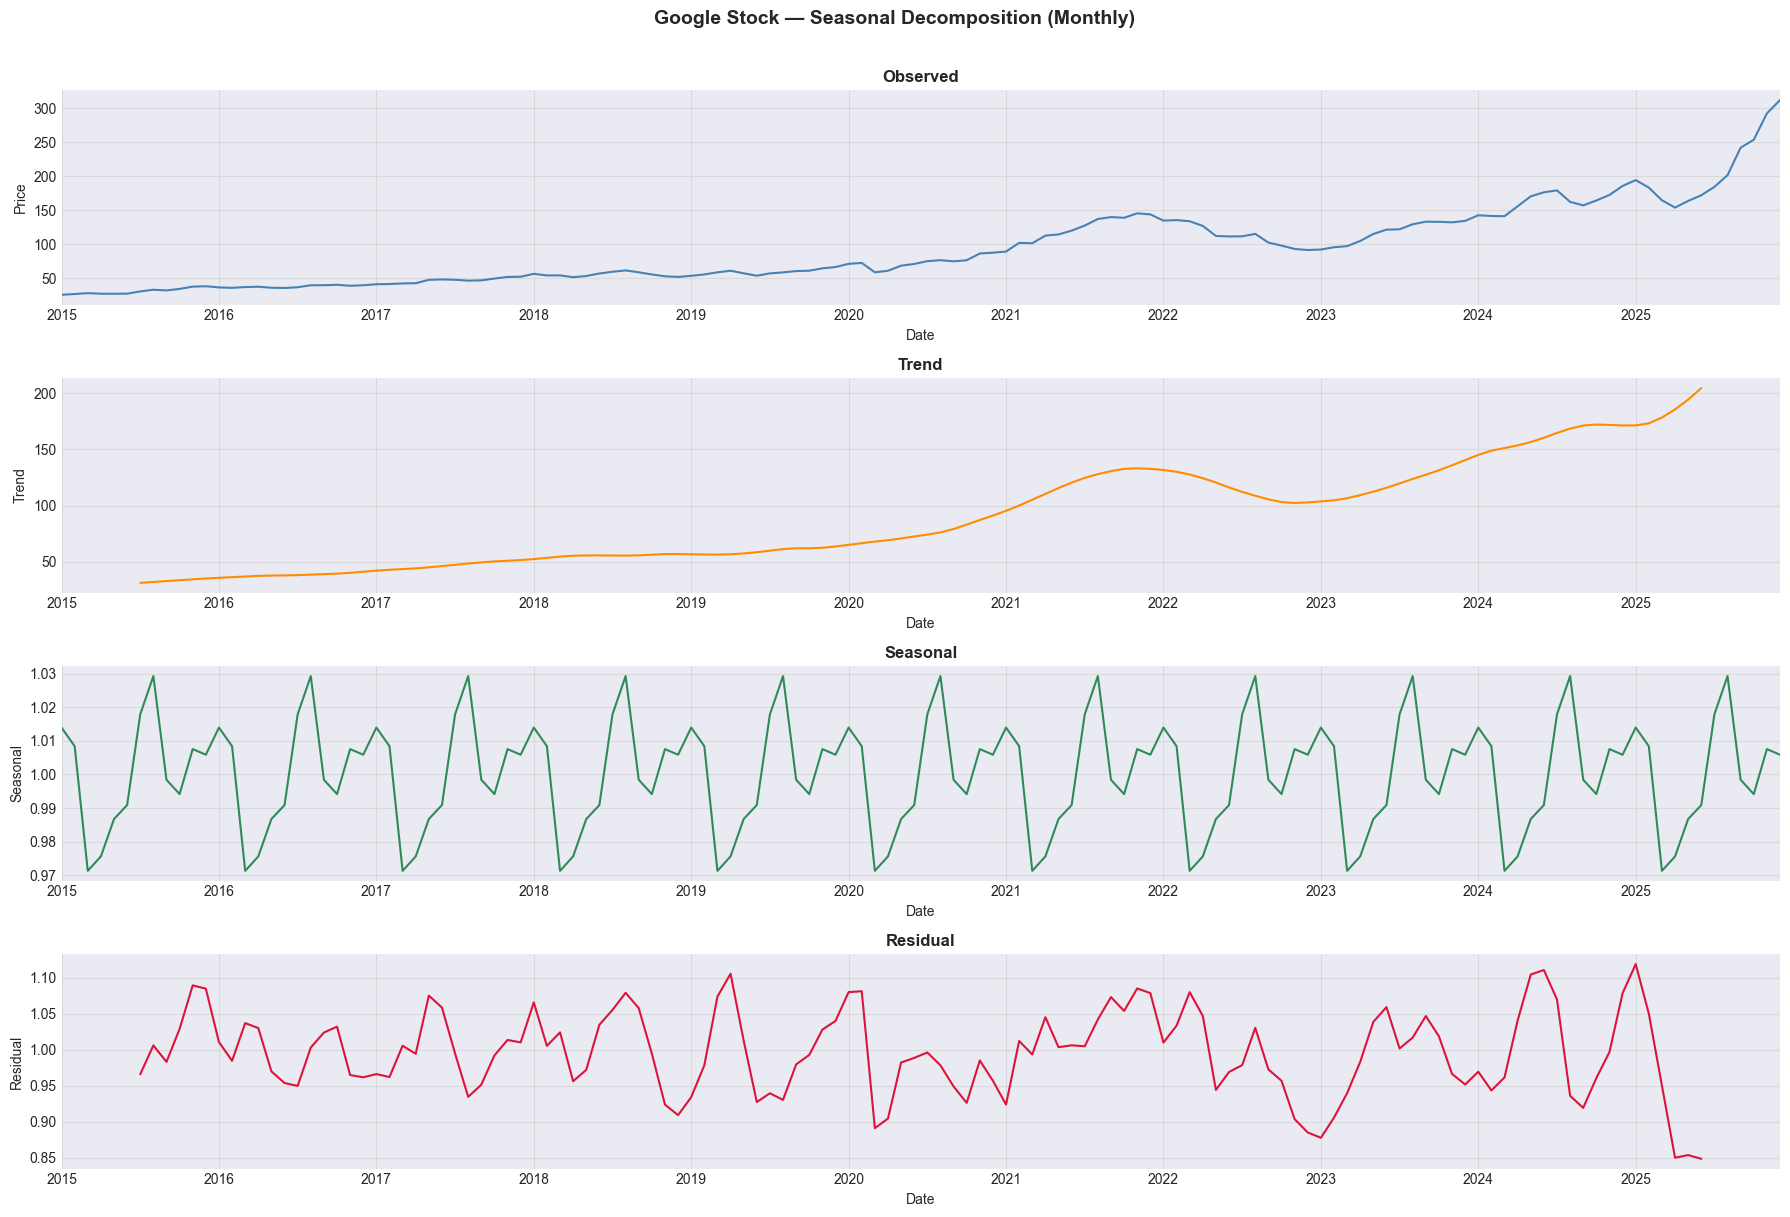

In [18]:
close_series = df.set_index('Date')['Close']
close_monthly = close_series.resample('M').mean()

decomposition = seasonal_decompose(close_monthly, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(18, 12))
decomposition.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_title('Observed',  fontweight='bold'); axes[0].set_ylabel('Price')
decomposition.trend.plot(ax=axes[1],    color='darkorange'); axes[1].set_title('Trend',     fontweight='bold'); axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='seagreen');   axes[2].set_title('Seasonal',  fontweight='bold'); axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3],    color='crimson');    axes[3].set_title('Residual',  fontweight='bold'); axes[3].set_ylabel('Residual')
for ax in axes: ax.grid(color='lightgray', alpha=0.7)
plt.suptitle('Google Stock — Seasonal Decomposition (Monthly)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/raw/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. EDA SUMMARY

| Observation | Finding |
|---|---|
| Price Trend | Strong long-term upward trend |
| Volatility | Daily returns near-normally distributed, mean ≈ 0 |
| Moving Averages | 100-day MA crosses 200-day MA at key trend change points |
| Feature Correlation | OHLC prices are highly correlated; Volume is independent |
| Seasonality | Mild seasonal pattern visible in decomposition |